In [1]:
import os
import sys
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import zoom
from mpl_toolkits.mplot3d import Axes3D

from tqdm.notebook import tqdm

sys.path.append("/home/cygnus/fujimoto/Cygnus-X_Molecular_Cloud_Analysis/Binary_classification/training/models")
from Binary_classification import Binary_classification_3 as model

In [2]:
weight_path = "/home/cygnus/fujimoto/Cygnus-X_Molecular_Cloud_Analysis/Binary_classification/training/save_dir/control_experiment-FGN_01100-03000_val-FGN03100~03300_GELU-model.pth"
weight_para = torch.load(weight_path, map_location=torch.device('cpu'))

In [3]:
model = model(latent=100, input_depth=30, input_height=100, input_width=100)
model.load_state_dict(weight_para)

<All keys matched successfully>

In [4]:
class DataSet():
    def __init__(self, data, label):
        self.label = label
        self.data = data
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, index):
        return self.data[index], self.label[index]

In [5]:
def load_and_sample_data(region_dict, is_bubble=False, bubble_filename="slide_bubble_data.npy", train_name=None):
    all_selected_data = []
    # 領域ごとのカウントを保持するリストを別途作成
    counts_per_reg = []
    # 領域ごとのランダムインデックスを保持するリスト
    indices_list = []

    for reg, num_to_sample in tqdm(region_dict.items()):
        combined_region_data = None
        
        if is_bubble:
            region_data_list = []
            ranks = bubble_config.get(reg, [])
            for rank in ranks:
                path = f"{base_path}/{reg}/Rank_Bubble/{rank}/{bubble_filename}"
                if os.path.exists(path):
                    region_data_list.append(np.load(path))
                else:
                    print(f"Info: No data for {reg} {rank}. Skipping append.")
            if region_data_list:
                combined_region_data = np.concatenate(region_data_list)
        else:
            path = f"{base_path}/{reg}/thresh_up_low/lower-1.66_data.npy"
            if os.path.exists(path):
                combined_region_data = np.load(path)

        # --- サンプリング処理 ---
        if combined_region_data is not None and len(combined_region_data) > 0:
            current_size = len(combined_region_data)
            actual_sample_size = min(num_to_sample, current_size)
            indices = np.random.choice(current_size, size=actual_sample_size, replace=False)
            indices.sort()

            if not is_bubble:
                # 潜在変数解析のためにランダムインデックスの保存
                save_index_path = f"/home/cygnus/fujimoto/Cygnus-X_Molecular_Cloud_Analysis/Binary_classification/training/training_data_indices/{reg}"
                Path(save_index_path).mkdir(parents=True, exist_ok=True)
                np.save(f"{save_index_path}/{train_name}", indices)
                indices_list.append(indices)

            sampled = combined_region_data[indices]
            all_selected_data.append(sampled) # データがある時だけリストに入れる
            counts_per_reg.append(len(sampled)) # 実際のサンプル数を記録
        else:
            # データがない場合はリストに追加せず、カウントだけ 0 にする
            counts_per_reg.append(0)

    if is_bubble:
        # データのリスト, 個数のリスト, インデックス番号
        return all_selected_data, counts_per_reg
    else:
        return np.concatenate(all_selected_data) if all_selected_data else np.array([]), indices_list

In [6]:
def reload_trainig_data(region_dict, data_type):
    all_selected_data = []
    # 領域ごとのカウントを保持するリストを別途作成
    counts_per_reg = []

    for reg, num_to_sample in tqdm(region_dict.items()):
        combined_region_data = None

        path = f"{base_path}/{reg}/thresh_up_low/lower-1.66_data.npy"
        if os.path.exists(path):
            combined_region_data = np.load(path)

        # --- サンプリング処理 ---
        if combined_region_data is not None and len(combined_region_data) > 0:
            if data_type == "training":
                random_indices_path = f"/home/cygnus/fujimoto/Cygnus-X_Molecular_Cloud_Analysis/Binary_classification/training/training_data_indices/{reg}/control_experiment-FGN_01100-03000_val-FGN03100~03300_upgrage-model.npy"
            elif data_type == "test":
                random_indices_path = f"/home/cygnus/fujimoto/Cygnus-X_Molecular_Cloud_Analysis/Binary_classification/training/training_data_indices/{reg}/control_experiment-FGN_01100-01500_val-FGN03100~03300_test_upgrade-model.npy"
            indices = np.load(random_indices_path)
            sampled = combined_region_data[indices]
            all_selected_data.append(sampled) # データがある時だけリストに入れる
            counts_per_reg.append(len(sampled)) # 実際のサンプル数を記録
        else:
            # データがない場合はリストに追加せず、カウントだけ 0 にする
            counts_per_reg.append(0)

    return np.concatenate(all_selected_data) if all_selected_data else np.array([]), counts_per_reg


def load_bubble_data(region_dict, bubble_filename="slide_bubble_data.npy"):
    all_selected_data = []
    # 領域ごとのカウントを保持するリストを別途作成
    counts_per_reg = []

    for reg, num_to_sample in tqdm(region_dict.items()):
        combined_region_data = None
        
        region_data_list = []
        ranks = bubble_config.get(reg, [])
        for rank in ranks:
            path = f"{base_path}/{reg}/Rank_Bubble/{rank}/{bubble_filename}"
            if os.path.exists(path):
                region_data_list.append(np.load(path))
            else:
                print(f"Info: No data for {reg} {rank}. Skipping append.")
        if region_data_list:
            combined_region_data = np.concatenate(region_data_list)

        if combined_region_data is not None and len(combined_region_data) > 0:
            all_selected_data.append(combined_region_data) # データがある時だけリストに入れる
            counts_per_reg.append(len(combined_region_data)) # 実際のサンプル数を記録
        else:
            # データがない場合はリストに追加せず、カウントだけ 0 にする
            counts_per_reg.append(0)

    # データのリスト, 個数のリスト, インデックス番号
    return all_selected_data, counts_per_reg

In [7]:
# テストpath
fits_path = "/home/cygnus/fujimoto/Cygnus-X_Molecular_Cloud_Analysis/fits/Galaxy_Plane/FUGIN/12CO/FGN_03300+0000_2x2_12CO_v1.00_cube.fits"

# 基本設定
base_path = "/home/cygnus/fujimoto/Cygnus-X_Molecular_Cloud_Analysis/Binary_classification/data/FUGIN/processed_data"

# 領域ごとのロード設定 (領域名: 抽出したいデータ数)
# もし全データロードしたい場合は None や非常に大きい数値を指定してください
data_num = 700
target_regions = {
    "FGN_01100+0000": data_num,
    "FGN_01200+0000": data_num,
    "FGN_01300+0000": data_num,
    "FGN_01400+0000": data_num,
    "FGN_01500+0000": data_num,
    "FGN_01600+0000": data_num,
    "FGN_01700+0000": data_num,
    "FGN_01800+0000": data_num,
    "FGN_01900+0000": data_num,
    "FGN_02000+0000": data_num,
    "FGN_02100+0000": data_num,
    "FGN_02200+0000": data_num,
    "FGN_02300+0000": data_num,
    "FGN_02400+0000": data_num,
    "FGN_02500+0000": data_num,
    "FGN_02600+0000": data_num,
    "FGN_02700+0000": data_num,
    "FGN_02800+0000": data_num,
    "FGN_02900+0000": data_num,
    "FGN_03000+0000": data_num,
}

# バブルのランク設定
bubble_config = {
    "FGN_01100+0000": ["Rank1"],
    "FGN_01200+0000": ["Rank1"],
    "FGN_01300+0000": ["Rank1"],
    "FGN_01400+0000": ["Rank1"],
    "FGN_01500+0000": ["Rank1"],
    "FGN_01600+0000": ["Rank1"],
    "FGN_01700+0000": ["Rank1"],
    "FGN_01800+0000": ["Rank1"],
    "FGN_01900+0000": ["Rank1"],
    "FGN_02000+0000": ["Rank1"],
    "FGN_02100+0000": ["Rank1"],
    "FGN_02200+0000": ["Rank1"],
    "FGN_02300+0000": ["Rank1"],
    "FGN_02400+0000": ["Rank1"],
    "FGN_02500+0000": ["Rank1"],
    "FGN_02600+0000": ["Rank1"],
    "FGN_02700+0000": ["Rank1"],
    "FGN_02800+0000": ["Rank1"],
    "FGN_02900+0000": ["Rank1"],
    "FGN_03000+0000": ["Rank1"],
    # "FGN_03100+0000": ["Rank1", "Rank2", "Rank3"],
    # "FGN_03200+0000": ["Rank1", "Rank2", "Rank3"],
    # "FGN_03300+0000": ["Rank1", "Rank2", "Rank3"],
    "FGN_03400+0000": ["Rank1", "Rank2", "Rank3"],
    "FGN_03500+0000": ["Rank1", "Rank2", "Rank3"],
}

In [8]:
# 2. 検証データのロード
# 特定の数だけ欲しい場合はここで指定
test_request = {"FGN_03400+0000": 150,
                "FGN_03500+0000": 150}
test_bubble, count_ = load_and_sample_data(test_request, is_bubble=True, bubble_filename="bubble_data.npy")
test_bubble = np.concatenate(test_bubble)
print(count_)

  0%|          | 0/2 [00:00<?, ?it/s]

[28, 18]


In [9]:
first_test = False
if first_test:
    test_no_bubbe, _ = load_and_sample_data(test_request, is_bubble=False, train_name="control_experiment-FGN_01100-01500_val-FGN03100~03300_test_upgrade-model.npy")
else:
    test_no_bubbe, _ = reload_trainig_data(test_request, data_type="test")

  0%|          | 0/2 [00:00<?, ?it/s]

In [10]:
# 3. ラベル付け
test_bubble_label = [1] * len(test_bubble)
test_data_label = [0] * len(test_no_bubbe)

In [11]:
test_data = np.concatenate((test_bubble, test_no_bubbe))
test_label = np.concatenate((test_bubble_label, test_data_label))
test_dataset = DataSet(test_data, test_label)
test_dataloader = DataLoader(test_dataset, batch_size=1, shuffle=True)

In [12]:
# # ==========================================
# # 1. データをPyTorchテンソルに変換・整形
# # ==========================================
# # NumPy配列をFloat型のテンソルに変換
# input_tensor = torch.from_numpy(my_data_array).float()

# # 形状を (30, 100, 100) -> (1, 1, 30, 100, 100) に拡張
# input_tensor = input_tensor.unsqueeze(0).unsqueeze(0)

# # Grad-CAM++ の勾配計算のために requires_grad を True に設定
# input_tensor.requires_grad_()

In [143]:
input_tensor = iter(test_dataloader)
input_tensor, label_tensor = next(input_tensor)
print(label_tensor)
input_tensor = input_tensor.float().unsqueeze(0)

tensor([0])


In [144]:
# ==========================================
# 2. Grad-CAM++ 計算関数の定義
# ==========================================
def compute_gradcam_plus_plus(model, input_tensor, target_layer, my_label, target_size=(30, 100, 100)):
    activations = None
    gradients = None

    def forward_hook(module, input, output):
        nonlocal activations
        activations = output

    def backward_hook(module, grad_input, grad_output):
        nonlocal gradients
        gradients = grad_output[0]

    handle_forward = target_layer.register_forward_hook(forward_hook)
    handle_backward = target_layer.register_full_backward_hook(backward_hook)

    # Forward
    model.zero_grad()
    out, latent_out = model(input_tensor)

    # 予測された確率の確認
    predicted_prob = out[0, 0].item()
    print(f"--- 推論結果 ---")
    print(f"正解ラベル: {my_label}")
    print(f"予測確率 (クラス1である確率): {predicted_prob:.4f}")
    print(f"予測クラス: {1 if predicted_prob >= 0.5 else 0}")
    print(f"----------------")

    # 二値分類スコアを逆伝播
    score = out[0, 0]
    score.backward()

    handle_forward.remove()
    handle_backward.remove()

    # Grad-CAM++ アルゴリズム
    A = activations.detach()
    grads_1 = gradients.detach()
    grads_2 = torch.pow(grads_1, 2)
    grads_3 = torch.pow(grads_1, 3)

    sum_A = torch.sum(A, dim=(2, 3, 4), keepdim=True)
    alpha_denom = 2 * grads_2 + sum_A * grads_3
    alpha_denom = torch.where(alpha_denom != 0.0, alpha_denom, torch.ones_like(alpha_denom))
    alpha = grads_2 / alpha_denom

    weights = torch.sum(alpha * F.relu(grads_1), dim=(2, 3, 4), keepdim=True)

    cam = torch.sum(weights * A, dim=1, keepdim=True)
    cam = F.relu(cam)

    # 元のサイズに3Dリサイズ
    cam = F.interpolate(cam, size=target_size, mode='trilinear', align_corners=False)
    
    # 0〜1に正規化
    cam = cam.squeeze().cpu().numpy()
    if cam.max() - cam.min() > 0:
        cam = (cam - cam.min()) / (cam.max() - cam.min())
        
    return cam

In [145]:
# ==========================================
# 3. 実行
# ==========================================
# 構築済みの学習済みモデルをセットアップ（重みロード等は事前に行ってください）
model.eval()

# 一番最後の畳み込み層をターゲットに指定
target_layer = model.features[7]

my_label = 1


# 実行して (30, 100, 100) のNumPy配列としてヒートマップを取得
result_cam = compute_gradcam_plus_plus(
    model=model, 
    input_tensor=input_tensor, 
    target_layer=target_layer, 
    my_label=label_tensor,
    target_size=(30, 100, 100)
)


print("\nGrad-CAM++ の抽出完了。形状:", result_cam.shape)

--- 推論結果 ---
正解ラベル: tensor([0])
予測確率 (クラス1である確率): 0.0000
予測クラス: 0
----------------

Grad-CAM++ の抽出完了。形状: (30, 100, 100)


In [146]:
import os
import cv2
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# --- 前提条件の設定（前回のコードの出力を利用） ---
# input_tensor: 形状 (1, 1, 30, 100, 100)
# result_cam: 形状 (30, 100, 100) ※0〜1に正規化されたGrad-CAM++の出力

# データの取り出しと整形
# 入力画像（3D）を (30, 100, 100) にし、可視化のために0〜1に正規化します
img_3d = input_tensor[0, 0].detach().cpu().numpy()
print(img_3d.min(), img_3d.max())
if img_3d.max() - img_3d.min() > 0:
    img_3d = (img_3d - img_3d.min()) / (img_3d.max() - img_3d.min())


0.0 0.7663954


In [147]:
# アニメーション用のフレームを格納するリスト
frames = []

fig, ax = plt.subplots(figsize=(6, 6))
ax.axis('off')  # 軸を非表示にする

# 30スライス分をループ処理
depth_size = result_cam.shape[0]
for d in range(depth_size):
    # 1. 各スライスのデータを取得
    slice_img = img_3d[d]          # 形状: (100, 100)
    slice_cam = result_cam[d]      # 形状: (100, 100)
    
    # 2. 入力画像をRGB（3チャンネル）に変換
    # matplotlibで扱うために、0-255のuint8型に変換します
    slice_img_uint8 = (slice_img * 255).astype(np.uint8)
    bg_rgb = cv2.cvtColor(slice_img_uint8, cv2.COLOR_GRAY2RGB)
    
    # 3. CAM（ヒートマップ）をJETカラーマップに変換
    slice_cam_uint8 = (slice_cam * 255).astype(np.uint8)
    heatmap_bgr = cv2.applyColorMap(slice_cam_uint8, cv2.COLORMAP_JET)
    heatmap_rgb = cv2.cvtColor(heatmap_bgr, cv2.COLOR_BGR2RGB)
    
    # 4. 元画像とヒートマップを重ね合わせる（alpha値で透明度を調整）
    alpha = 0.4
    overlay = cv2.addWeighted(heatmap_rgb, alpha, bg_rgb, 1 - alpha, 0)
    
    # 5. アニメーション用のプロットを作成
    # スライス番号をタイトルに表示
    title = ax.text(0.5, 1.05, f"Slice: {d:02d}/{depth_size-1}", 
                    size=plt.rcParams["axes.titlesize"],
                    ha="center", transform=ax.transAxes)

    # 画像を表示オブジェクトとして追加
    im = ax.imshow(overlay, animated=True, cmap="jet")
    
    # フレームに登録（画像とタイトルテキストをセットにする）
    frames.append([im, title])

# アニメーションの設定（intervalは各フレームの表示時間：ミリ秒単位）
ani = animation.ArtistAnimation(fig, frames, interval=200, blit=True, repeat_delay=1000)

# GIFアニメーションとして保存
output_filename = "grad_cam_plus_plus_3d.gif"
ani.save(output_filename, writer="pillow")
plt.close()

# print(f"GIFアニメーションを保存しました: {os.path.abspath(output_filename)}")

In [148]:
gelu = nn.GELU()

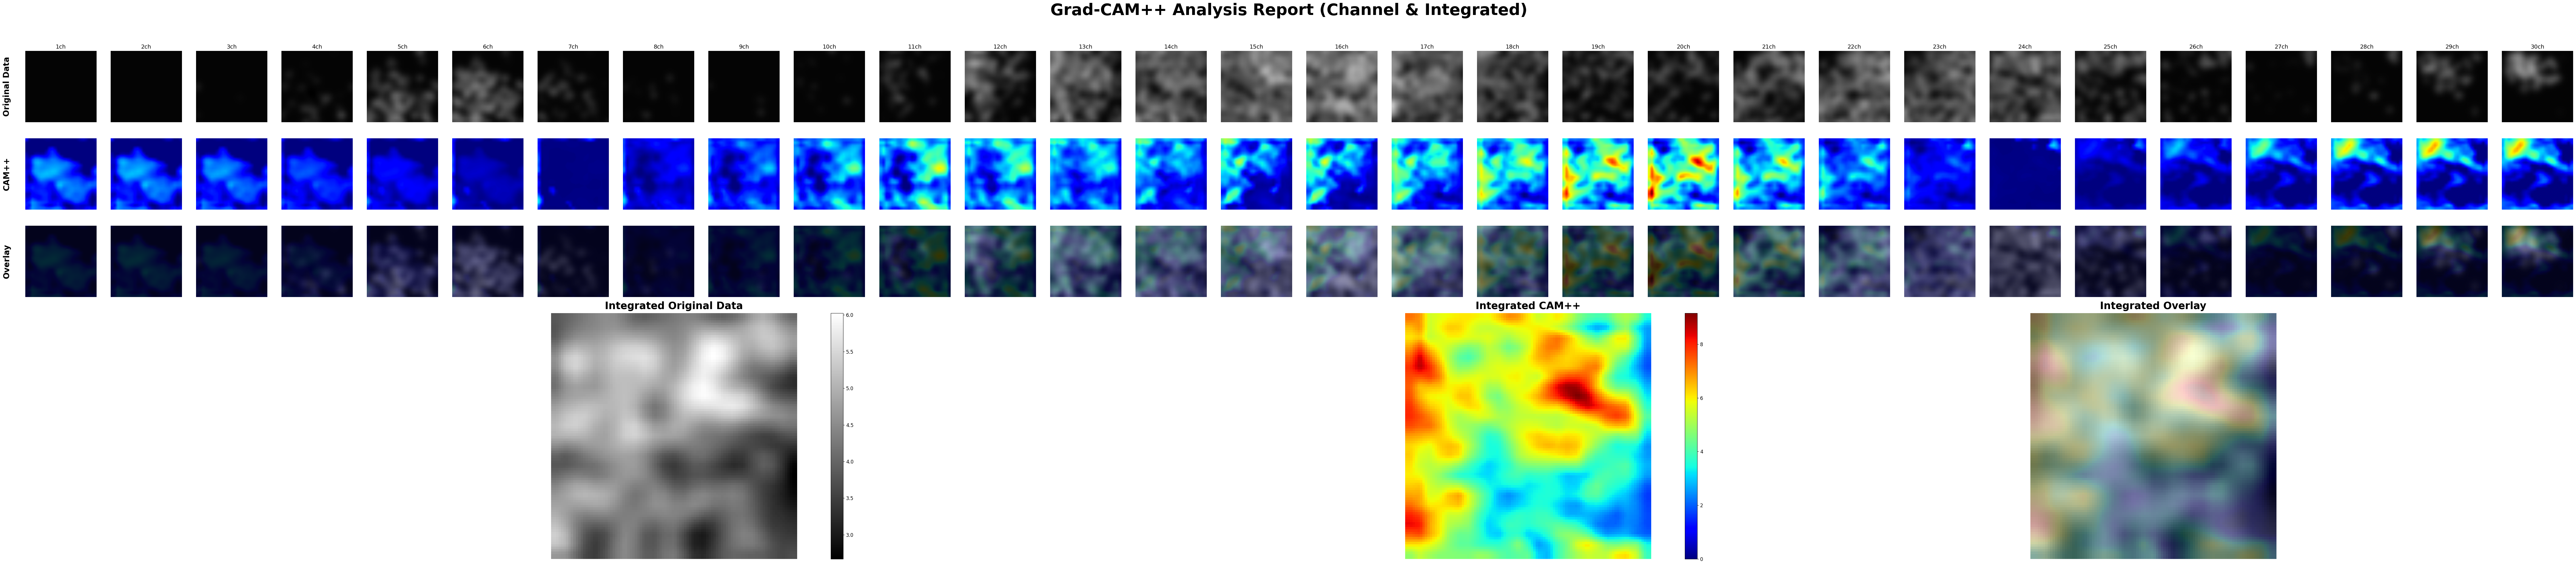

In [149]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# --- データの準備（既存の処理） ---
axes_num = result_cam.shape[0]
data_cam = result_cam

origin_data = input_tensor.numpy().squeeze()
if origin_data.ndim == 2:
    origin_data = np.expand_dims(origin_data, axis=0)
    axes_num = 1

# 下段用の各種積分強度図の作成（元のスケールのまま足し合わせ）
integrated_origin = np.sum(origin_data, axis=0)
integrated_cam = np.sum(data_cam, axis=0) 

# --- 画面レイアウトの設定 ---
col_resolution = axes_num * 3

# 縦方向に6行分のスペースを確保
fig = plt.figure(figsize=(max(12, axes_num * 3), 5 * 4))
gs = gridspec.GridSpec(6, col_resolution, figure=fig)

alpha = 0.2
cam_cmap = plt.get_cmap("jet") 
# ※元のコードの "Grays" から、matplotlib標準の "Gray"（または "gray"）に修正しています
origin_cmap = plt.get_cmap("gray")

# --- 【上段】チャンネルごとのマップ (行0: Original, 行1: CAM, 行2: Overlay) ---
for j in range(axes_num):
    img_org = origin_data[j]
    img_cam = data_cam[j]
    
    # 既存のスケールを維持したRGB変換
    org_rgb = origin_cmap(img_org)[:, :, :3]
    cam_rgb = cam_cmap(img_cam)[:, :, :3]
    overlay_rgb = (1 - alpha) * org_rgb + alpha * cam_rgb
    
    col_start = j * 3
    col_end = (j + 1) * 3
    
    # (行0) Original Data
    ax_org = fig.add_subplot(gs[0, col_start:col_end])
    ax_org.imshow(img_org, cmap=origin_cmap, vmin=0, vmax=1)
    ax_org.axis("off")
    if j == 0:
        ax_org.text(-0.2, 0.5, "Original Data", va='center', ha='right', 
                    transform=ax_org.transAxes, fontsize=20, fontweight='bold', rotation=90)
    ax_org.set_title(f"{j+1}ch", fontsize=14)

    # (行1) CAM Heatmap
    ax_cam = fig.add_subplot(gs[1, col_start:col_end])
    ax_cam.imshow(img_cam, vmin=0, vmax=1, cmap=cam_cmap)
    ax_cam.axis("off")
    if j == 0:
        ax_cam.text(-0.2, 0.5, "CAM++", va='center', ha='right', 
                    transform=ax_cam.transAxes, fontsize=20, fontweight='bold', rotation=90)

    # (行2) Overlay
    ax_ovl = fig.add_subplot(gs[2, col_start:col_end])
    ax_ovl.imshow(overlay_rgb)
    ax_ovl.axis("off")
    if j == 0:
        ax_ovl.text(-0.2, 0.5, "Overlay", va='center', ha='right', 
                    transform=ax_ovl.transAxes, fontsize=20, fontweight='bold', rotation=90)


# --- 【下段】3枚の積分強度図（行3〜5を縦にぶち抜き、横方向に3等分） ---
step = col_resolution // 3

# 1. 元データの積分強度図
ax_int_org = fig.add_subplot(gs[3:6, 0:step])
im_org = ax_int_org.imshow(integrated_origin, cmap=origin_cmap)
ax_int_org.axis("off")
ax_int_org.set_title("Integrated Original Data", fontsize=25, fontweight='bold', pad=10)
# カラーバーを追加（サイズと位置をグラフの高さに合わせる）
cbar_org = fig.colorbar(im_org, ax=ax_int_org, orientation='vertical', fraction=0.046, pad=0.04)
cbar_org.ax.tick_params(labelsize=12)

# 2. CAMの積分強度図
ax_int_cam = fig.add_subplot(gs[3:6, step:step*2])
im_cam = ax_int_cam.imshow(integrated_cam, vmin=0, vmax=integrated_cam.max(), cmap=cam_cmap)
ax_int_cam.axis("off")
ax_int_cam.set_title("Integrated CAM++", fontsize=25, fontweight='bold', pad=10)
# カラーバーを追加
cbar_cam = fig.colorbar(im_cam, ax=ax_int_cam, orientation='vertical', fraction=0.046, pad=0.04)
cbar_cam.ax.tick_params(labelsize=12)

# 3. 積分強度図のオーバーレイ
int_org_scaled = (integrated_origin - integrated_origin.min()) / (integrated_origin.max() - integrated_origin.min() + 1e-8)
int_cam_scaled = (integrated_cam - integrated_cam.min()) / (integrated_cam.max() - integrated_cam.min() + 1e-8)

int_org_rgb = origin_cmap(int_org_scaled)[:, :, :3]
int_cam_rgb = cam_cmap(int_cam_scaled)[:, :, :3]
integrated_overlay_rgb = (1 - alpha) * int_org_rgb + alpha * int_cam_rgb

ax_int_ovl = fig.add_subplot(gs[3:6, step*2:col_resolution])
ax_int_ovl.imshow(integrated_overlay_rgb)
ax_int_ovl.axis("off")
ax_int_ovl.set_title("Integrated Overlay", fontsize=25, fontweight='bold', pad=10)


# --- 全体の調整と保存 ---
fig.suptitle("Grad-CAM++ Analysis Report (Channel & Integrated)", fontsize=40, fontweight='bold', y=0.98)

# 【修正】rect引数を追加して、最上部（y=0.93以上）をメインタイトルのために空けて自動レイアウトを適用します
plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.savefig("cam_horizontal_integrated_report_Non_02.png", bbox_inches='tight', dpi=150)
plt.show()